In [2]:
import os
import h5py
import mediapy as media
import matplotlib.pyplot as plt

def load_hdf5(dataset_path):
    if not os.path.isfile(dataset_path):
        print(f'Dataset does not exist at \n{dataset_path}\n')
        exit()

    with h5py.File(dataset_path, 'r') as root:
        qpos = root['/observations/qpos'][()]
        qvel = root['/observations/qvel'][()]
        image_dict = dict()
        for cam_name in root[f'/observations/images/'].keys():
            image_dict[cam_name] = root[f'/observations/images/{cam_name}'][()]
        action = root['/action'][()]

    return qpos, qvel, action, image_dict

/home/vivekbagade/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# play cam video
data_file = '/act-data/PickPlaceCan/episodes/1.1.0/episode_0.hdf5'
qpos, qvel, action, image_dict = load_hdf5(dataset_path=data_file)
for cam_name, image_list in image_dict.items():
    media.show_video(image_list, fps=30)

This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


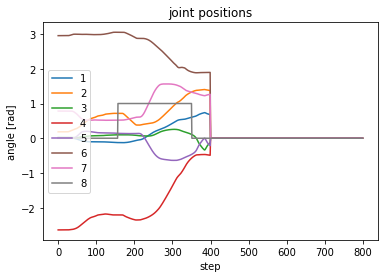

In [4]:
# plot qpos
plt.figure()
plt.plot(qpos, label=list(range(1, 9)))
plt.xlabel('step')
plt.ylabel('angle [rad]')
plt.title('joint positions')
plt.legend()